# Predicting Hepatitis C 🩺

#### If you like my work, It will be really great of you to upvote this notebook!
#### If not then you leaving a comment on what do I need to work on and improve will be really helpful!

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("dataset-uci.csv")  # replace with your path

# Preview
print(df.head())
print(df['Gallstone Status'].value_counts())

   Gallstone Status  Age  Gender  Comorbidity  Coronary Artery Disease (CAD)  \
0                 0   50       0            0                              0   
1                 0   47       0            1                              0   
2                 0   61       0            0                              0   
3                 0   41       0            0                              0   
4                 0   42       0            0                              0   

   Hypothyroidism  Hyperlipidemia  Diabetes Mellitus (DM)  Height  Weight  \
0               0               0                       0     185    92.8   
1               0               0                       0     176    94.5   
2               0               0                       0     171    91.1   
3               0               0                       0     168    67.7   
4               0               0                       0     178    89.6   

   ...  High Density Lipoprotein (HDL)  Triglyceride  \


In [21]:
X = df.drop(columns=['Gallstone Status'])  # target column assumed to be 'Gallstones'
y = df['Gallstone Status']

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

y_pred = cross_val_predict(model, X_scaled, y, cv=cv)

Stratified Logistic Regression Accuracy: 0.7774


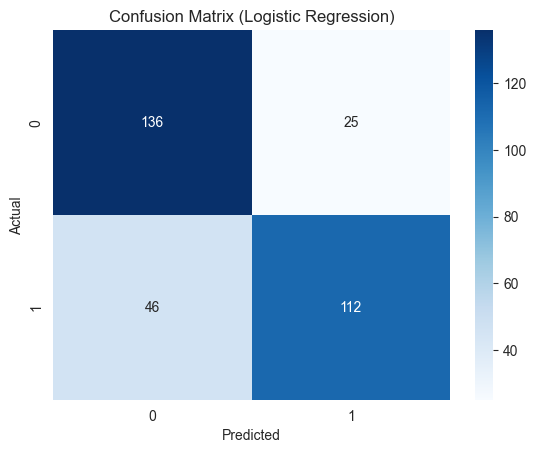

In [24]:
acc = accuracy_score(y, y_pred)
print(f"Stratified Logistic Regression Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()


In [25]:
print("Classification Report:")
print(classification_report(y, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       161
           1       0.82      0.71      0.76       158

    accuracy                           0.78       319
   macro avg       0.78      0.78      0.78       319
weighted avg       0.78      0.78      0.78       319

